# 1.6 — The distribution, as code

02805 Social Graphs and Interactions, week 1.

The Marvel network: 303 Wikipedia articles for Marvel characters, with an arc from A to B
when A's article links to B's. Frozen snapshot, so every group computes on identical data.

Four parts:

1. Load it without losing the isolates, and reconcile the directed and undirected edge counts
2. In- and out-degree distributions, linear and log-log, checked against the explorable's leaderboard
3. The course's binning scheme, implemented and verified against the raw points
4. An exponential and a power-law specimen, and which one the real in-degree resembles

## Setup

In [1]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# validated for colour-blind separation on all pairs (see notebook 01)
BLUE, ORANGE, GREEN = "#2a78d6", "#eb6834", "#1baf7a"
INK, MUTED, GRID = "#2B2B2B", "#6B6B6B", "#DDDDDD"

DATA = "../data"

def style(ax, xlabel, ylabel):
    ax.set_xlabel(xlabel, fontsize=9, color=MUTED)
    ax.set_ylabel(ylabel, fontsize=9, color=MUTED)
    ax.tick_params(labelsize=8, colors=MUTED, length=0)
    ax.grid(True, color=GRID, linewidth=0.6)
    ax.set_axisbelow(True)
    for s in ax.spines.values():
        s.set_visible(False)

## 1. Load it, keeping the isolates

The trap the course flags: build the graph from the edge list alone and the 17 characters with
no links in either direction never get created. Adding the full node roster **first** is what
keeps them.

In [2]:
nodes = pd.read_csv(f"{DATA}/week1_nodes.tsv", sep="\t", comment="#")
edges = pd.read_csv(f"{DATA}/week1_edges.tsv", sep="\t", comment="#",
                    names=["source", "target"])

D = nx.DiGraph()
D.add_nodes_from(nodes.node_id)                               # isolates survive because of this line
D.add_edges_from(edges.itertuples(index=False, name=None))

name = dict(zip(nodes.node_id, nodes.name))
N = D.number_of_nodes()

print(f"nodes            {N}")
print(f"directed edges   {D.number_of_edges()}")
print(f"isolates         {len(list(nx.isolates(D)))}")

assert N == 303
assert D.number_of_edges() == 1784
assert len(list(nx.isolates(D))) == 17

nodes            303
directed edges   1784
isolates         17


In [3]:
# what happens if you skip the roster
D_naive = nx.from_pandas_edgelist(edges, create_using=nx.DiGraph)
print(f"edge list only:  {D_naive.number_of_nodes()} nodes  ({N - D_naive.number_of_nodes()} characters lost)")

edge list only:  286 nodes  (17 characters lost)


### Reconciling with Part 2's undirected numbers

In [4]:
U = D.to_undirected()
m = U.number_of_edges()
mean_k = 2 * m / N

print(f"undirected edges m   {m}")
print(f"mean degree <k>      {mean_k:.3f}")
print(f"directed - undirected {D.number_of_edges() - m}")

assert m == 1434
assert round(mean_k, 1) == 9.5

undirected edges m   1434
mean degree <k>      9.465
directed - undirected 350


**Why the two counts differ:** 350 pairs of characters link to each other in both directions,
and collapsing to undirected turns each of those mutual pairs into a single edge, so
1784 − 350 = 1434.

Sanity check on that claim below.

In [5]:
mutual = sum(1 for u, v in D.edges() if D.has_edge(v, u)) // 2
print(f"mutual pairs                {mutual}")
print(f"1784 - {mutual} = {1784 - mutual}   (matches m = {m}: {1784 - mutual == m})")

mutual pairs                350
1784 - 350 = 1434   (matches m = 1434: True)


## 2. The distributions

$P(k)$ is the fraction of characters with degree exactly $k$. Everything is plotted against
**k + 1**, because a log axis has no place to put zero and 20 characters have out-degree 0.

In [6]:
def raw_pk(degrees, N):
    """Raw P(k), returned against u = k + 1 so it survives a log axis."""
    u, counts = np.unique(np.asarray(degrees) + 1, return_counts=True)
    return u, counts / N

k_in = [d for _, d in D.in_degree()]
k_out = [d for _, d in D.out_degree()]

for label, ks in [("in", k_in), ("out", k_out)]:
    u, p = raw_pk(ks, N)
    print(f"{label:>3}-degree: max k = {max(ks):>3}   zeros = {sum(1 for k in ks if k == 0):>2}   "
          f"sum P(k) = {p.sum():.6f}")

assert np.isclose(raw_pk(k_in, N)[1].sum(), 1.0)
assert np.isclose(raw_pk(k_out, N)[1].sum(), 1.0)

 in-degree: max k = 106   zeros = 58   sum P(k) = 1.000000
out-degree: max k =  28   zeros = 20   sum P(k) = 1.000000


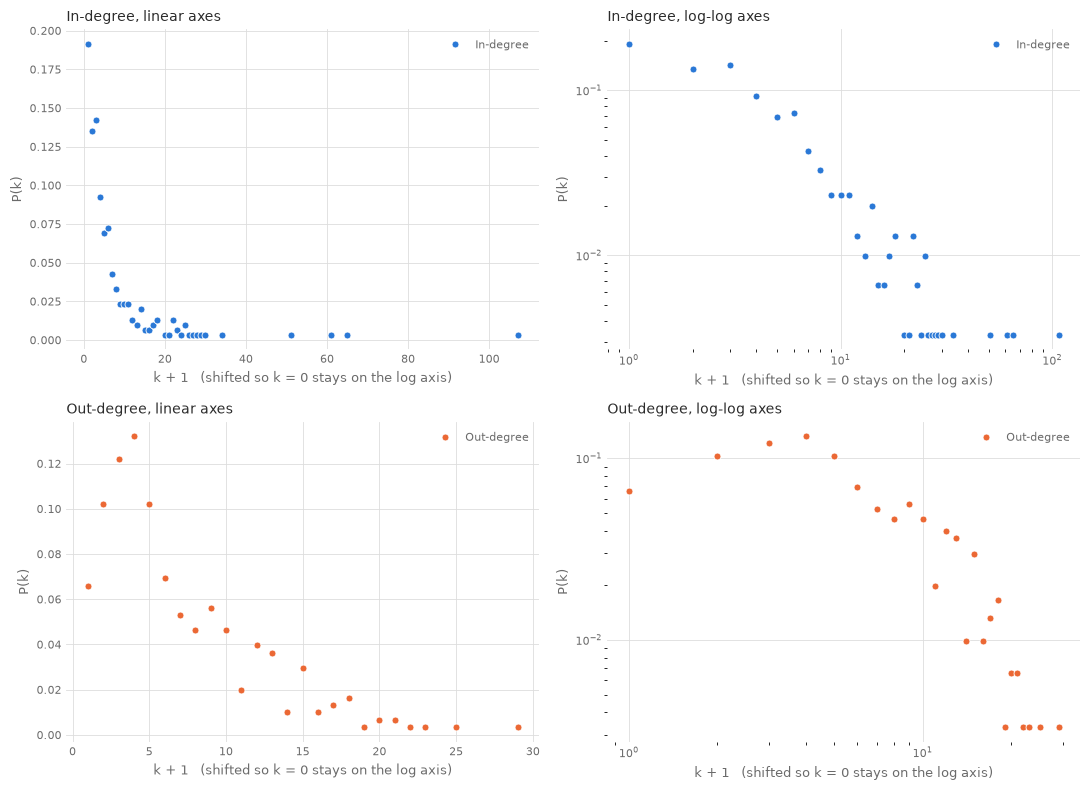

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

series = [("In-degree", k_in, BLUE), ("Out-degree", k_out, ORANGE)]

for row, (label, ks, colour) in enumerate(series):
    u, p = raw_pk(ks, N)
    for col, logscale in enumerate([False, True]):
        ax = axes[row, col]
        ax.plot(u, p, "o", color=colour, markersize=5, markeredgecolor="white",
                markeredgewidth=0.6, label=label)
        if logscale:
            ax.set_xscale("log")
            ax.set_yscale("log")
        style(ax, "k + 1   (shifted so k = 0 stays on the log axis)", "P(k)")
        ax.set_title(f"{label}, {'log-log' if logscale else 'linear'} axes",
                     fontsize=10, color=INK, loc="left")
        ax.legend(frameon=False, fontsize=8, labelcolor=MUTED)

fig.tight_layout()
fig.savefig("figures/marvel_pk_raw.png", dpi=200, bbox_inches="tight")
plt.show()

### Leaderboards, checked against the explorable

In [8]:
def leaderboard(degree_view, n=5):
    return [(name[node], d) for node, d in sorted(degree_view, key=lambda kv: -kv[1])[:n]]

print("TOP 5 BY IN-DEGREE (linked to most)")
for i, (nm, d) in enumerate(leaderboard(D.in_degree()), 1):
    print(f"  {i}. {nm} - {d}")

print()
print("TOP 5 BY OUT-DEGREE (links out most)")
for i, (nm, d) in enumerate(leaderboard(D.out_degree()), 1):
    print(f"  {i}. {nm} - {d}")

# the explorable's out-degree leaderboard, read off the screenshot
expected_out = [("Betsy Braddock", 28), ("Cloak and Dagger (characters)", 24),
                ("Adam Warlock", 22), ("Venom (character)", 21), ("She-Hulk", 20)]
assert leaderboard(D.out_degree()) == expected_out
assert leaderboard(D.in_degree())[0] == ("Spider-Man", 106)
print()
print("Both leaderboards match the explorable.")

TOP 5 BY IN-DEGREE (linked to most)
  1. Spider-Man - 106
  2. Hulk - 64
  3. Wolverine (character) - 60
  4. Doctor Strange - 50
  5. Deadpool - 33

TOP 5 BY OUT-DEGREE (links out most)
  1. Betsy Braddock - 28
  2. Cloak and Dagger (characters) - 24
  3. Adam Warlock - 22
  4. Venom (character) - 21
  5. She-Hulk - 20

Both leaderboards match the explorable.


Two different populations, as exercise 1.4 argues. Spider-Man tops the in-degree at 106
because other editors keep deciding he is worth mentioning. Betsy Braddock tops the out-degree
at 28 because someone sat down and wrote 28 links into her article. One is conferred and has no
ceiling; the other is authored and is limited by how long an article anyone bothers to write.

## 3. The binning scheme

From the Goodies note: **width-1 bins for u = 1 … 7, then doubling bins** [8,16), [16,32),
[32,64), [64,128). Each bin's count is divided by its width, so a wide bin is not popular
merely for being wide, and each bin is drawn at the **geometric mean** of the degrees it covers.

The test that matters: where the bins are width 1 the binned curve must land exactly on the raw
points. If it doesn't, the normalization is wrong.

In [9]:
def bin_edges(umax):
    """Width-1 bins for u = 1..7, doubling bins after that."""
    e = list(range(1, 9))          # [1,2) ... [7,8)
    hi = 8
    while hi <= umax:
        e.append(hi * 2)           # [8,16), [16,32), ...
        hi *= 2
    return np.array(e)

def binned_pk(degrees, N):
    """Probability density per unit of degree, drawn at each bin's geometric mean."""
    u = np.asarray(degrees) + 1
    e = bin_edges(u.max())
    counts, _ = np.histogram(u, bins=e)
    widths = np.diff(e)
    density = counts / (widths * N)                     # divide by width AND by N
    centres = np.array([np.exp(np.mean(np.log(np.arange(lo, hi))))
                        for lo, hi in zip(e[:-1], e[1:])])
    keep = counts > 0
    return centres[keep], density[keep], e

print("bin edges:", bin_edges(max(k_in) + 1))

bin edges: [  1   2   3   4   5   6   7   8  16  32  64 128]


In [10]:
# the normalization check
for label, ks in [("in", k_in), ("out", k_out)]:
    ru, rp = raw_pk(ks, N)
    bu, bp, _ = binned_pk(ks, N)
    width1 = bu <= 7                                   # the width-1 region
    for x, y in zip(bu[width1], bp[width1]):
        j = np.where(np.isclose(ru, x))[0]
        assert len(j) == 1 and np.isclose(rp[j[0]], y), f"{label}: mismatch at u={x}"
    print(f"{label:>3}-degree: binned == raw at all {width1.sum()} width-1 bins")

print()
print("Normalization verified: the binned curve coincides with the raw points where it must.")

 in-degree: binned == raw at all 7 width-1 bins
out-degree: binned == raw at all 7 width-1 bins

Normalization verified: the binned curve coincides with the raw points where it must.


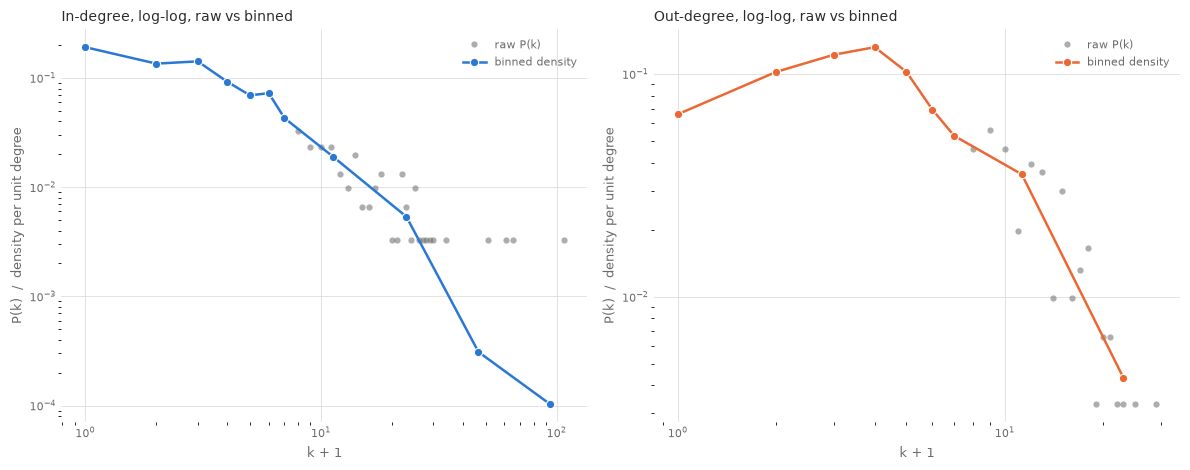

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

for ax, (label, ks, colour) in zip(axes, series):
    ru, rp = raw_pk(ks, N)
    bu, bp, _ = binned_pk(ks, N)
    ax.plot(ru, rp, "o", color=MUTED, markersize=4.5, alpha=0.55,
            markeredgecolor="none", label="raw P(k)")
    ax.plot(bu, bp, "-o", color=colour, markersize=6, linewidth=1.8,
            markeredgecolor="white", markeredgewidth=0.8, label="binned density")
    ax.set_xscale("log")
    ax.set_yscale("log")
    style(ax, "k + 1", "P(k)  /  density per unit degree")
    ax.set_title(f"{label}, log-log, raw vs binned", fontsize=10, color=INK, loc="left")
    ax.legend(frameon=False, fontsize=8, labelcolor=MUTED)

fig.tight_layout()
fig.savefig("figures/marvel_pk_binned.png", dpi=200, bbox_inches="tight")
plt.show()

**Where the extra range came from.** Out in the tail every raw count is 0 or 1: one character
at k = 106, nobody at 105 or 107. A log axis cannot draw the zeros at all, so the raw curve simply
stops. Binning pools those isolated 1s and 0s into a bin wide enough to hold a meaningful average,
which puts a plottable point where the raw data had only gaps. The range was hiding, not invented.
What binning cannot do is add information: the [64,128) bin still rests on a handful of characters.

## 4. Two specimens, and which one the real data resembles

**Sampling a power law by inverse transform.** For $p(x) \propto x^{-\alpha}$ with $x \ge x_{min}$,
the complementary CDF is $P(X \ge x) = (x/x_{min})^{1-\alpha}$. Setting that equal to a uniform
$r \in (0,1]$ and solving:

$$x = x_{min}\, r^{-1/(\alpha - 1)}$$

The exponential specimen needs no trick; numpy samples it directly.

In [12]:
rng = np.random.default_rng(42)
n_samples = 10_000

# exponential specimen
exp_k = np.floor(rng.exponential(scale=10.0, size=n_samples)).astype(int)

# power-law specimen, by inverse transform
alpha, xmin = 2.5, 1.0
r = rng.random(n_samples)
pl_k = np.floor(xmin * r ** (-1 / (alpha - 1))).astype(int)

print(f"exponential : mean {exp_k.mean():6.2f}   max {exp_k.max():>5}")
print(f"power law   : mean {pl_k.mean():6.2f}   max {pl_k.max():>5}   (alpha = {alpha})")
print(f"real in-deg : mean {np.mean(k_in):6.2f}   max {max(k_in):>5}")

exponential : mean   9.39   max    95
power law   : mean   2.73   max  1392   (alpha = 2.5)
real in-deg : mean   5.89   max   106


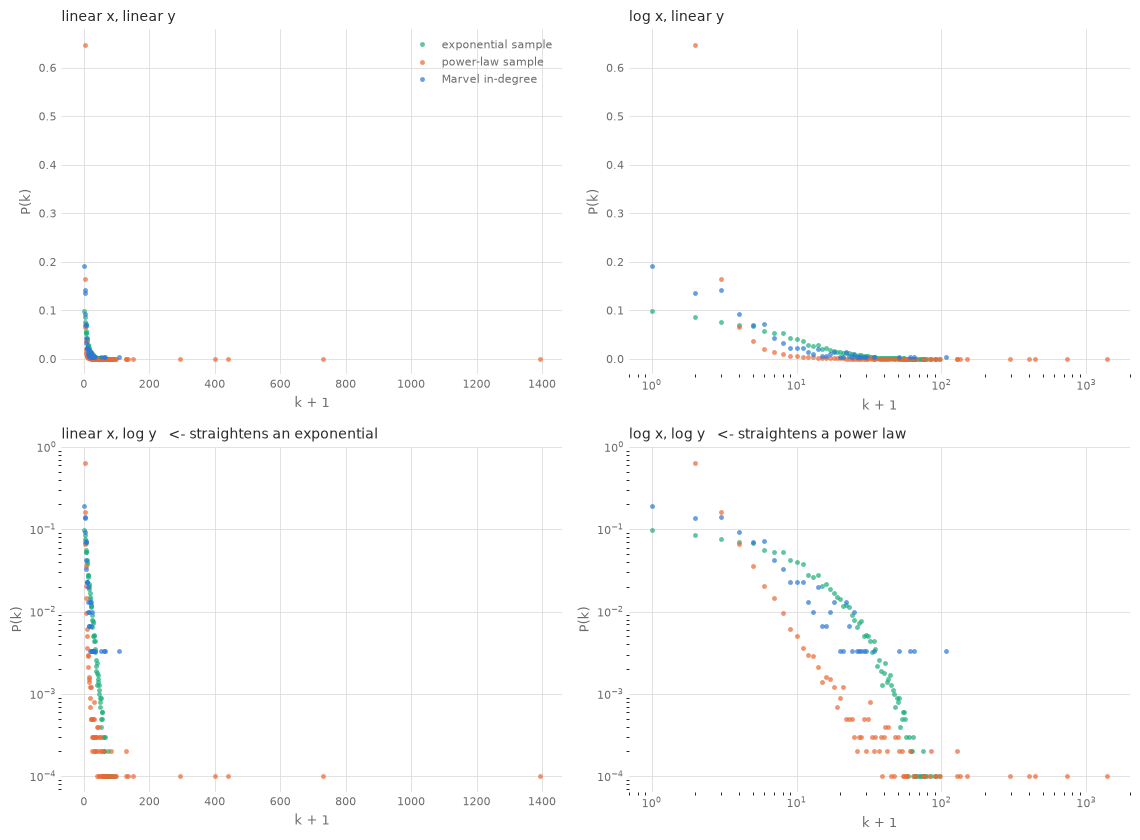

In [13]:
specimens = [("exponential sample", exp_k, GREEN),
             ("power-law sample", pl_k, ORANGE),
             ("Marvel in-degree", np.array(k_in), BLUE)]

fig, axes = plt.subplots(2, 2, figsize=(11.5, 8.5))
combos = [(False, False, "linear x, linear y"), (True, False, "log x, linear y"),
          (False, True, "linear x, log y   <- straightens an exponential"),
          (True, True, "log x, log y   <- straightens a power law")]

for ax, (logx, logy, title) in zip(axes.ravel(), combos):
    for label, ks, colour in specimens:
        u, p = raw_pk(ks, len(ks))
        ax.plot(u, p, "o", color=colour, markersize=3.5, alpha=0.7,
                markeredgecolor="none", label=label)
    if logx:
        ax.set_xscale("log")
    if logy:
        ax.set_yscale("log")
    style(ax, "k + 1", "P(k)")
    ax.set_title(title, fontsize=10, color=INK, loc="left")

axes[0, 0].legend(frameon=False, fontsize=8, labelcolor=MUTED)
fig.tight_layout()
fig.savefig("figures/marvel_specimens.png", dpi=200, bbox_inches="tight")
plt.show()

### How sure are you?

Straightness has a number: fit a line in each transformed space and read off $R^2$. High on
**lin-log** means exponential-ish; high on **log-log** means power-law-ish.

Fitting the *raw* points here, not the binned ones. Exercise 1.4 asks whether you should ever fit
a slope to a binned plot, and the answer is no: binning has already thrown away the per-point
uncertainty the fit would need. Treat these numbers as a shape diagnostic, not an estimate of
$\alpha$. The honest way to get an exponent is maximum likelihood on the raw degrees.

In [14]:
def straightness(degrees):
    """R^2 of a straight-line fit in lin-log space and in log-log space."""
    u, p = raw_pk(degrees, len(degrees))
    keep = p > 0
    u, p = u[keep], p[keep]
    out = {}
    for label, x in [("lin-log", u), ("log-log", np.log10(u))]:
        y = np.log10(p)
        slope, icept = np.polyfit(x, y, 1)
        resid = y - (slope * x + icept)
        out[label] = 1 - resid.var() / y.var()
    return out

print(f"{'series':<22}{'R2 lin-log':>12}{'R2 log-log':>12}   verdict")
for label, ks, _ in specimens:
    s = straightness(ks)
    verdict = "power-law-ish" if s["log-log"] > s["lin-log"] else "exponential-ish"
    print(f"{label:<22}{s['lin-log']:>12.3f}{s['log-log']:>12.3f}   {verdict}")

series                  R2 lin-log  R2 log-log   verdict
exponential sample           0.961       0.823   exponential-ish
power-law sample             0.088       0.707   power-law-ish
Marvel in-degree             0.428       0.850   power-law-ish


The two specimens behave as advertised, which is the point of having them: they calibrate your
eye before you look at data whose answer you do not know. Read each row against **itself**, never
across rows.

| series | R² lin-log | R² log-log | leans |
|---|---|---|---|
| exponential sample | 0.961 | 0.823 | exponential |
| power-law sample | 0.088 | 0.707 | power law |
| Marvel in-degree | 0.428 | 0.850 | power law |

Two traps are visible in that table.

**The exponential scores 0.823 on log-log.** A high log-log R² on its own proves nothing: the known
exponential is nearly straight there too. Only the *comparison* with its own lin-log score, 0.961,
gives the right answer. This is the arithmetic behind the warning that a straight-ish log-log plot
is weak evidence.

**Marvel out-scores the genuine power law**, 0.850 against 0.707, and that ranking is meaningless.
The synthetic sample has 10,000 draws reaching k = 1392, so most of its range is tail where every
count is 1 and the points scatter wildly. Marvel stops at k = 106. More data bought the specimen a
longer, noisier tail and a worse fit, which is the opposite of what a naive reading suggests. R²
compares straightness within a range; it does not compare across two different ranges.

So: the Marvel in-degree leans power-law, in the same direction and for the same reason as the
specimen. How sure am I? Not very. 303 nodes, a single point at k = 106, and a tail where every
count is 0 or 1 is thin ground, and the proper test is maximum likelihood plus a goodness-of-fit
statistic on the raw degrees. Week 2.